In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("drunk_driving_realistic.csv")
df.head()

,country,min_drinking_age,alcohol_consumption,population,young_driver_count,traffic_fatalities,drunk_driving_rate
0,United States,21,9.23,87589652,4234933,13475,17.30
1,Canada,19,5.84,91705612,291784,7899,2.51
2,Germany,20,9.18,13975873,603885,13689,8.98
3,France,16,10.51,29237948,2559867,16741,12.69
4,United Kingdom,17,3.16,119424617,2904401,11156,7.66


uses structured dataset, also uses real world data from the World Health Organization and OECD. the data that is provided shows alchohol does affect drunk driving accident rates


In [34]:
print(df.isnull().sum())

df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))

# FIXED category conversion
df["rate_category"] = pd.cut(
    df["drunk_driving_rate"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

country                0
min_drinking_age       0
alcohol_consumption    0
population             0
young_driver_count     0
traffic_fatalities     0
drunk_driving_rate     0
dtype: int64


In [35]:
from sklearn.model_selection import train_test_split

X = df[[
    "min_drinking_age",
    "alcohol_consumption",
    "population",
    "young_driver_count",
    "traffic_fatalities"
]]

y = df["rate_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40, 5)
(10, 5)


Features

all features are minimum drinking age, alchohol consumption, population, young driver count, traffic fatalities

World Health Organization and OECD say that these relate to traffic accident

y is characterized by low, medium, or high
previous variable was changed into categorieds for classification.

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
tree = DecisionTreeClassifier(random_state=42)
y = df["Cluster"]
tree.fit(X_train, y_train)

y_pred = tree.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_pred))
print(classification_report(y_train, y_pred))
print(confusion_matrix(y_train, y_pred))

Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         1
          17       1.00      1.00      1.00         1
          18       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         1
    

C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


Decision tree
\
the model shows a strong performance for the training data.

the accuracy score shows how a lot of the predicitons made were correct. the classification gives the precision, recall, and f1 scores

confucsion matrix shows how it lines up with actual data

high accuracy means theirs a chance that its overfitting and means its not generalizing well

In [52]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_train)

print("SVM Training Accuracy:", accuracy_score(y_train, svm_pred))
print(classification_report(y_train, svm_pred))


SVM Training Accuracy: 0.275
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       1.00      1.00      1.00         1
          17       0.00      0.00      0.00         1
          18       1.00      1.00      1.00         1
          20       0.00      0.00      0.00         

C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\svm\_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: Undef

In [53]:
from sklearn.metrics import confusion_matrix
import pandas as pd

final_pred = svm_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, final_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual Medium", "Actual High"],
    columns=["Pred Low", "Pred Medium", "Pred High"]
)

print("\nConfusion Matrix:\n")
print(cm_df)

Test Accuracy: 0.0

Classification Report:

              precision    recall  f1-score   support

           4       0.00      0.00      0.00       1.0
           8       0.00      0.00      0.00       1.0
          10       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       1.0
          19       0.00      0.00      0.00       1.0
          21       0.00      0.00      0.00       1.0
          32       0.00      0.00      0.00       1.0
          33       0.00      0.00      0.00       1.0
          38       0.00      0.00      0.00       1.0
          40       0.00      0.00      0.00       1.0
          41       0.00      0.00      0.00       0.0
          43       0.00      0.00      0.00       1.0

    accuracy                           0.00      10.0
   macro avg       0.00      0.00      0.00      10.0
weighted avg       0.00      0.00      0.00      10.0



C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\S559619\ml-venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\S559619\ml-venv\Lib\site-pa

ValueError: Shape of passed values is (12, 12), indices imply (3, 3)

clean the data before making the model to remove duplicates and take out missing data which helps ensure that the dataset is correct.

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

# Select features (adjust column names to your dataset)
X = df.select_dtypes(include=['float64', 'int64'])

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [55]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

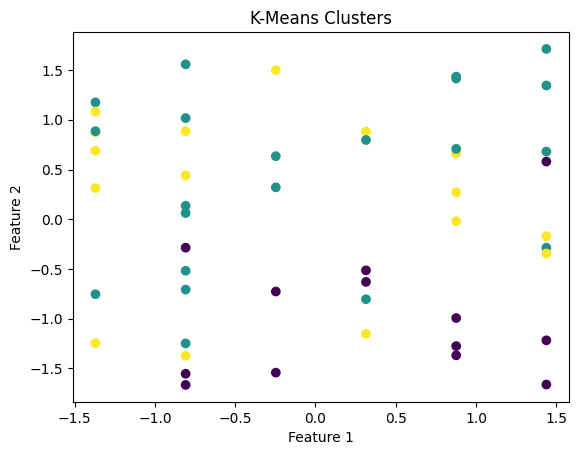

In [56]:
import matplotlib.pyplot as plt

plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=clusters)
plt.title("K-Means Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.30031345 0.23438739]


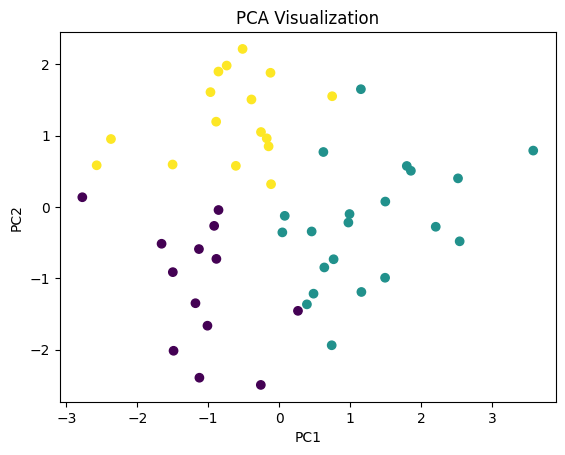

In [58]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [59]:
import numpy as np

z_scores = np.abs((X - X.mean()) / X.std())
outliers = (z_scores > 3)

print("Outliers per column:\n", outliers.sum())

Outliers per column:
 min_drinking_age       0
alcohol_consumption    0
population             0
young_driver_count     0
traffic_fatalities     0
drunk_driving_rate     0
dtype: int64


create training and test sets
this section will make two different sets which are the training and test sets.
the test set will be used to test its perfomance and the training set will be used train the model

In [60]:
from sklearn.model_selection import train_test_split

X = df[[
    "min_drinking_age",
    "alcohol_consumption",
    "population",
    "young_driver_count",
    "traffic_fatalities"]]

y = df["drunk_driving_rate"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (40, 5)
Test shape: (10, 5)


In [61]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(max_iter=500)
nn.fit(X_train, y_train)

nn_pred = nn.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, nn_pred))

ValueError: Unknown label type: (array([16.47,  7.66, 11.14, 11.21, 12.69, 16.42,  2.93, 12.96,  9.37,
        8.96, 17.03,  8.11,  9.92, 19.83, 11.68, 17.3 , 13.11,  9.8 ,
       11.34,  8.49, 13.44,  9.45, 14.18,  2.51,  6.21,  8.98, 13.35,
        8.21,  7.99, 11.11,  7.2 ,  8.54,  7.41, 11.26, 10.36,  9.82,
        9.7 ,  4.8 ,  9.31,  6.29]),)

the features that the data is based off of is minimum drinking age, alchohol consumption, population, amount of young drivers, and traffic fatalities."
The reason I chose this data is it will help reflect drunk driving rates.


In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)

print("Training R2:", r2_score(y_train, y_pred))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_pred)))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Training R2: 0.8187187402858089
Training RMSE: 1.5817826296435433
Coefficients: [1.63417532e-01 9.60522519e-01 3.52246265e-09 1.57277695e-06
 3.18332999e-05]
Intercept: -4.498778617076418


In [63]:
y_test_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Test R2: 0.672510017191242
Test RMSE: 1.521237142069072


Total Overview

Part A
Looking at the data we can see that the alchohol consumption rate and the number of young drivers in a country will directly affect the drunk driving accident rates.

Part B
using the r^2 and RMSE we trained the model then evaluated it

in the data we can also see that the alchohol consumption rates have a more direct influence on driving under the influence than the actual age of driving

there are many factors that come into play when influencing the data such as differences in culture, road laws, and law enforcement of the countries.

using this data and project we can see how machine learning can be used to see possible outcomes.


more overview

the project analyzed relationships bewtween alchohol consumption and drunk driving accident rates with the classification models

World Health organization and OECD data shows that the alchohol does in fact play a large role in traffic fatalities

Decision Tree
Decision tree did perform well for the training data but overfits the true datasset

SVM model
this helped make more accurate results

problems
-limited dataset size
-less detail due to the categories